In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
base = Path.cwd()
candidates = [base, base.parent, Path("/mnt/data")]
def locate(name):
    for p in candidates:
        q = p / name
        if q.exists():
            return q
    raise FileNotFoundError(name)
details = pd.read_csv(locate("order_details(3).csv"))
timestamps = pd.read_csv(locate("order_timestamp(3).csv"))
for c in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[c] = pd.to_datetime(timestamps[c], errors="coerce")
details["created_date"] = pd.to_datetime(details["created_date"], errors="coerce")
df = details.merge(timestamps, on="order_id", how="inner", validate="one_to_one")
df["BART_raw_min"] = (df["arrived_pickup_at"] - df["start_time_slot"]).dt.total_seconds()/60
df["BART_min"] = df["BART_raw_min"].clip(lower=0)
df["Acceptance_raw_min"] = (df["accept_time"] - df["start_time_slot"]).dt.total_seconds()/60
df["Acceptance_min"] = df["Acceptance_raw_min"].clip(lower=0)
df["Arrival_raw_min"] = (df["arrived_pickup_at"] - df["accept_time"]).dt.total_seconds()/60
df["Arrival_min"] = df["Arrival_raw_min"].clip(lower=0)
df["BART15"] = np.where(df["BART_min"].notna(), (df["BART_min"] <= 15).astype(int), np.nan)
df["hour"] = df["start_time_slot"].dt.hour
df["weekday"] = df["start_time_slot"].dt.day_name()
df["month"] = df["start_time_slot"].dt.month_name()
df["month_num"] = df["start_time_slot"].dt.month
df["date"] = df["start_time_slot"].dt.date
df["hour_bucket"] = df["start_time_slot"].dt.floor("h")
df["distance_km"] = df["total_distance"]/1000
df["fare_m"] = df["order_fare"]/1_000_000
df["fare_per_km"] = np.where(df["distance_km"]>0, df["order_fare"]/df["distance_km"], np.nan)
df["delayed_flag"] = np.where(df["order_offer_badge"].notna(), (df["order_offer_badge"].astype(str).str.lower()=="delayed").astype(int), np.nan)
df["district_str"] = df["district"].astype("Int64").astype(str)
df["city_district"] = df["order_city"].astype(str)+"-"+df["district_str"]
main = df[(df["start_time_slot"] >= pd.Timestamp("2025-08-01")) & (df["start_time_slot"] < pd.Timestamp("2025-11-01")) & df["BART_min"].notna()].copy()
seq = main[(main["start_time_slot"] <= main["accept_time"]) & (main["accept_time"] <= main["arrived_pickup_at"])].copy()
fig_dir = Path("assets/figures")
table_dir = Path("assets/tables")
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir/name, dpi=220, bbox_inches="tight")
    plt.show()
def save_table(data, name, decimals=2):
    x = data.copy()
    for c in x.select_dtypes(include=["float", "float64", "float32"]).columns:
        x[c] = x[c].round(decimals)
    display(x)


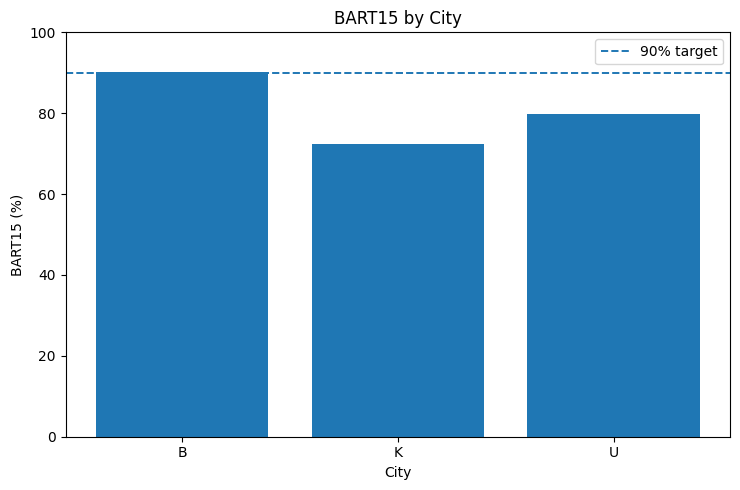

In [2]:
city = main.groupby("order_city").agg(Orders=("order_id","size"),BART15=("BART15","mean")).reset_index()
city["BART15"]*=100
fig, ax = plt.subplots(figsize=(7.5,5))
ax.bar(city["order_city"],city["BART15"])
ax.axhline(90,linestyle="--",linewidth=1.4,label="90% target")
ax.set_ylim(0,100)
ax.set_title("BART15 by City")
ax.set_xlabel("City")
ax.set_ylabel("BART15 (%)")
ax.legend()
savefig("F03_City_BART15.png")


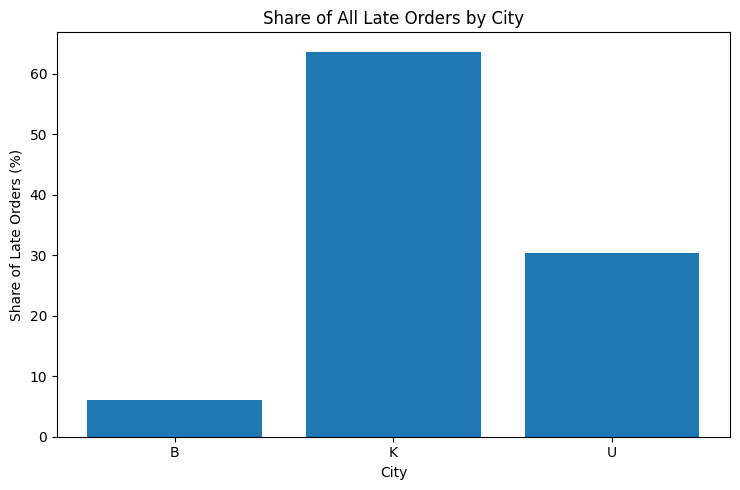

In [3]:
city_late = main.assign(Late=(main["BART15"]==0).astype(int)).groupby("order_city").agg(Late_Orders=("Late","sum")).reset_index()
city_late["Share_of_All_Late_Orders"] = city_late["Late_Orders"]/city_late["Late_Orders"].sum()*100
fig, ax = plt.subplots(figsize=(7.5,5))
ax.bar(city_late["order_city"],city_late["Share_of_All_Late_Orders"])
ax.set_title("Share of All Late Orders by City")
ax.set_xlabel("City")
ax.set_ylabel("Share of Late Orders (%)")
savefig("F04_City_Late_Order_Share.png")


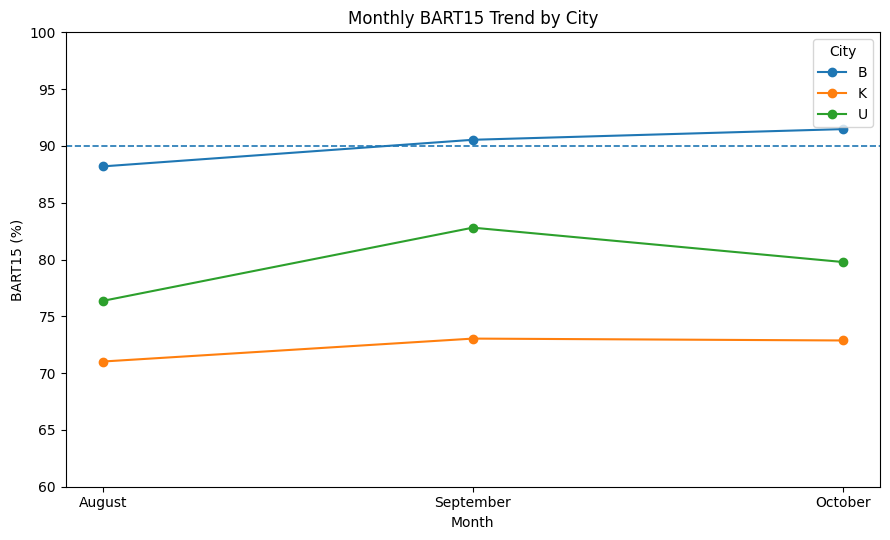

In [4]:
monthly = main.groupby(["order_city","month_num"])["BART15"].mean().mul(100).reset_index()
fig, ax = plt.subplots(figsize=(9,5.5))
for city_name,g in monthly.groupby("order_city"):
    ax.plot(g["month_num"],g["BART15"],marker="o",label=city_name)
ax.axhline(90,linestyle="--",linewidth=1.2)
ax.set_xticks([8,9,10],labels=["August","September","October"])
ax.set_ylim(60,100)
ax.set_title("Monthly BART15 Trend by City")
ax.set_xlabel("Month")
ax.set_ylabel("BART15 (%)")
ax.legend(title="City")
savefig("F05_Monthly_BART15_by_City.png")


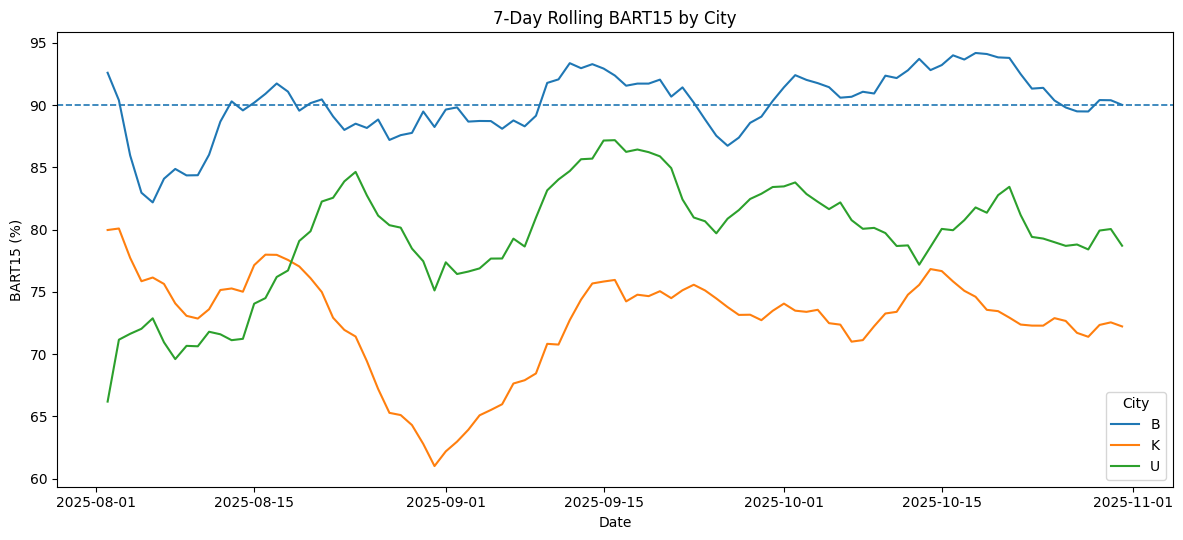

In [5]:
daily = main.groupby(["order_city","date"]).agg(Successes=("BART15","sum"),Orders=("BART15","size")).reset_index()
parts=[]
for city_name,g in daily.groupby("order_city"):
    g=g.sort_values("date").copy()
    g["Rolling_BART15"] = g["Successes"].rolling(7,min_periods=1).sum()/g["Orders"].rolling(7,min_periods=1).sum()*100
    parts.append(g)
roll=pd.concat(parts)
fig, ax = plt.subplots(figsize=(12,5.5))
for city_name,g in roll.groupby("order_city"):
    ax.plot(pd.to_datetime(g["date"]),g["Rolling_BART15"],label=city_name)
ax.axhline(90,linestyle="--",linewidth=1.2)
ax.set_title("7-Day Rolling BART15 by City")
ax.set_xlabel("Date")
ax.set_ylabel("BART15 (%)")
ax.legend(title="City")
savefig("F06_Seven_Day_Rolling_BART15_by_City.png")


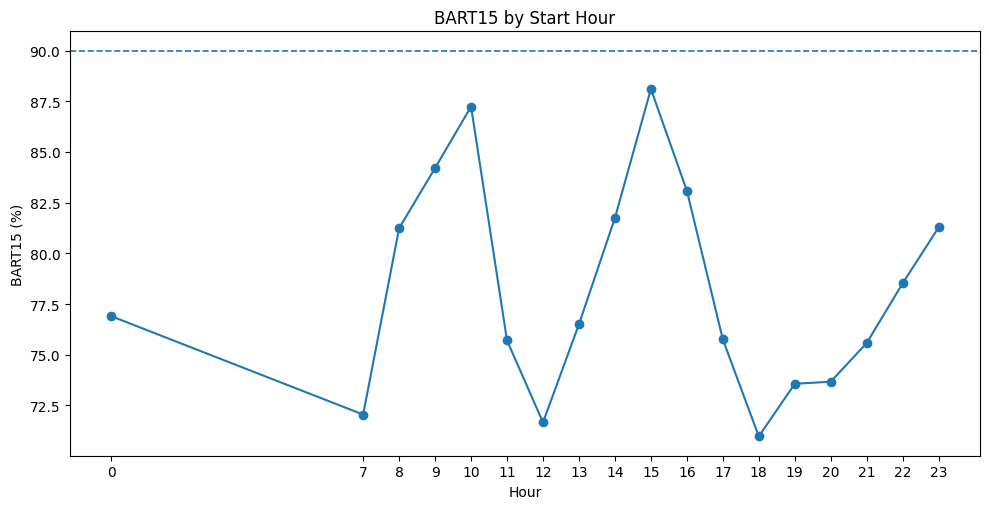

In [6]:
hourly = main.groupby("hour").agg(Orders=("order_id","size"),BART15=("BART15","mean"),Late_Orders=("BART15",lambda s:(s==0).sum())).reset_index()
hourly=hourly[hourly["Orders"]>=100]
fig, ax = plt.subplots(figsize=(10,5.2))
ax.plot(hourly["hour"],hourly["BART15"]*100,marker="o")
ax.axhline(90,linestyle="--",linewidth=1.2)
ax.set_xticks(hourly["hour"])
ax.set_title("BART15 by Start Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("BART15 (%)")
savefig("F07_Hourly_BART15.png")


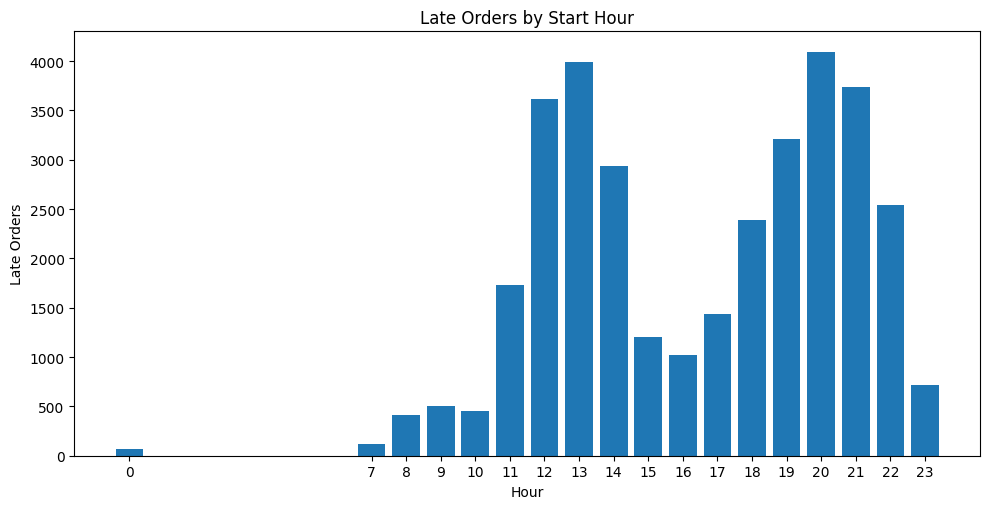

In [7]:
fig, ax = plt.subplots(figsize=(10,5.2))
ax.bar(hourly["hour"],hourly["Late_Orders"])
ax.set_xticks(hourly["hour"])
ax.set_title("Late Orders by Start Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Late Orders")
savefig("F08_Hourly_Late_Orders.png")


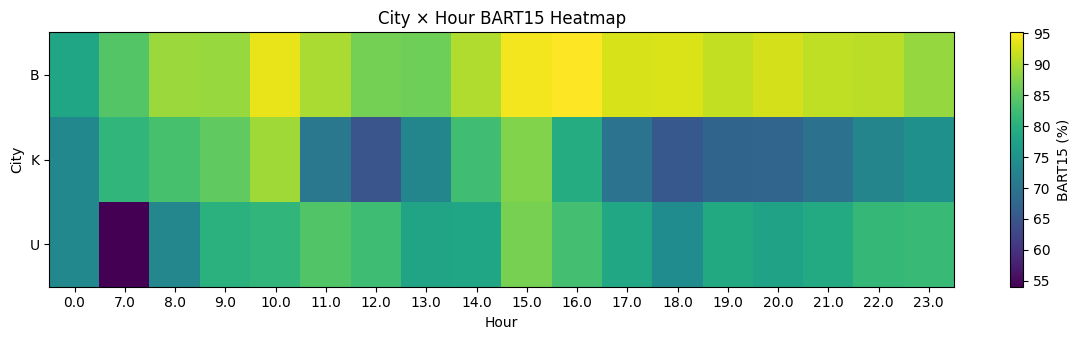

In [8]:
heat = main.groupby(["order_city","hour"])["BART15"].mean().mul(100).unstack("hour")
cols=[c for c in heat.columns if main[main["hour"]==c].shape[0]>=100]
heat=heat[cols]
fig, ax = plt.subplots(figsize=(12,3.5))
im=ax.imshow(heat.values,aspect="auto")
ax.set_yticks(range(len(heat.index)),labels=heat.index)
ax.set_xticks(range(len(heat.columns)),labels=heat.columns)
ax.set_title("City × Hour BART15 Heatmap")
ax.set_xlabel("Hour")
ax.set_ylabel("City")
cb=plt.colorbar(im,ax=ax)
cb.set_label("BART15 (%)")
savefig("F09_City_Hour_BART15_Heatmap.png")


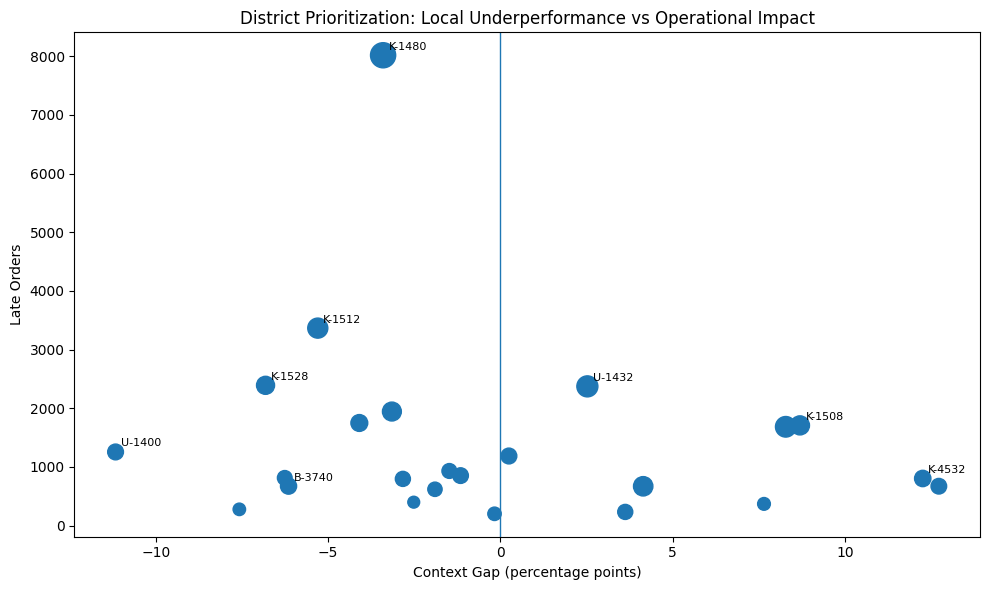

In [9]:
x = main.copy()
x["context"] = list(zip(x["order_city"],x["month_num"],x["weekday"],x["hour"]))
ctx = x.groupby(["order_city","month_num","weekday","hour","district"]).agg(N=("order_id","size"),Success=("BART15","sum")).reset_index()
tot = ctx.groupby(["order_city","month_num","weekday","hour"]).agg(AllN=("N","sum"),AllSuccess=("Success","sum")).reset_index()
ctx=ctx.merge(tot,on=["order_city","month_num","weekday","hour"],how="left")
ctx["RestN"]=ctx["AllN"]-ctx["N"]
ctx["RestSuccess"]=ctx["AllSuccess"]-ctx["Success"]
ctx=ctx[ctx["RestN"]>=30].copy()
ctx["Expected"] = ctx["RestSuccess"]/ctx["RestN"]
ctx["Observed"] = ctx["Success"]/ctx["N"]
ctx["Weight"] = ctx["N"]
rows=[]
for (city_name,district),g in ctx.groupby(["order_city","district"]):
    w=g["Weight"].to_numpy()
    rows.append({"City":city_name,"District":int(district),"Context_Matched_BART15":np.average(g["Observed"],weights=w)*100,"Expected_BART15":np.average(g["Expected"],weights=w)*100,"Context_Coverage_Orders":g["N"].sum()})
context=pd.DataFrame(rows)
raw=main.groupby(["order_city","district"]).agg(Orders=("order_id","size"),Raw_BART15=("BART15","mean"),Late_Orders=("BART15",lambda s:(s==0).sum())).reset_index()
raw=raw.rename(columns={"order_city":"City","district":"District"})
context=context.merge(raw,on=["City","District"],how="left")
context["Context_Gap_pp"]=context["Context_Matched_BART15"]-context["Expected_BART15"]
context["Area"]=context["City"]+"-"+context["District"].astype(str)
plot_context=context[(context["Orders"]>=250)&(~context["Area"].isin(["U-1412","U-1424"]))].copy()
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(plot_context["Context_Gap_pp"],plot_context["Late_Orders"],s=np.sqrt(plot_context["Orders"])*2)
ax.axvline(0,linewidth=1)
for area in ["U-1400","K-1480","K-1512","K-1528","B-3740","U-1432","K-1508","K-4532"]:
    r=plot_context[plot_context["Area"]==area]
    if len(r): ax.annotate(area,(r["Context_Gap_pp"].iloc[0],r["Late_Orders"].iloc[0]),xytext=(4,4),textcoords="offset points",fontsize=8)
ax.set_title("District Prioritization: Local Underperformance vs Operational Impact")
ax.set_xlabel("Context Gap (percentage points)")
ax.set_ylabel("Late Orders")
savefig("F10_Context_Gap_vs_Late_Orders.png")


In [10]:
top=context[(context["Orders"]>=250)&(~context["Area"].isin(["U-1412","U-1424"]))].sort_values("Context_Gap_pp").head(12)[["Area","Raw_BART15","Late_Orders","Context_Matched_BART15","Expected_BART15","Context_Gap_pp"]].copy()
top["Raw_BART15"]*=100
top=top.rename(columns={"Raw_BART15":"Raw BART15 (%)","Late_Orders":"Late Orders","Context_Matched_BART15":"Context-Matched BART15 (%)","Expected_BART15":"Expected BART15 (%)","Context_Gap_pp":"Context Gap (pp)"})
save_table(top,"T04_Context_Benchmark_Top_Underperformers.png")


,Area,Raw BART15 (%),Late Orders,Context-Matched BART15 (%),Expected BART15 (%),Context Gap (pp)
23,U-1400,69.82,1256,69.92,81.09,-11.17
2,B-3728,82.88,278,83.27,90.84,-7.58
17,K-1528,66.38,2392,66.27,73.09,-6.81
27,U-1416,74.15,814,74.09,80.35,-6.26
4,B-3740,85.16,674,85.67,91.81,-6.15
15,K-1512,69.01,3367,68.43,73.73,-5.30
10,K-1484,67.65,1750,67.70,71.80,-4.09
9,K-1480,70.19,8018,70.11,73.52,-3.40
30,U-1428,77.32,1945,77.13,80.28,-3.15
22,U-1396,77.03,797,77.11,79.94,-2.83
